    SELECT * FROM tables.d_orders;

#highest revenue generating products
use tables;

#here there are multiple  product_ids

with cte as (select * ,rank() over (partition by region,product_id order by saleprice desc) as grp from d_orders)
select region,product_id, sum(saleprice)  from cte group by product_id order by sum(saleprice) desc limit 10;

#top 5 selling products in each regioon

WITH sales_by_product AS ( select region, product_id , sum(saleprice) as totalsales from d_orders group by region, product_id)
, ctes as (select * ,rank() over (partition by region order by totalsales desc) as grp from sales_by_product)
select* from ctes where grp<=5 ;


#top5 selling products in each region

#we need to use partition by
#You group by both because sales belong to a specific product in a specific region.--
#You partition only by region because products must compete with each other inside that region.

WITH sales_by_product AS ( select region, product_id , sum(saleprice) as totalsales from d_orders group by region, product_id)
, ctes as (select * ,row_number() over (partition by region order by totalsales desc) as grp from sales_by_product)
select region,product_id, totalsales from ctes where grp<=5 ;

-- select * from d_orders where product_id in ('OFF-AP-10002311','FUR-CH-10000454 ');  
-- select region, product_id , sum(saleprice) as totalsales from d_orders whe-- re product_id in ('OFF-AP-10002311','FUR-CH-10000454') group by region, product_id ;

-- find month over month growth com for 2022 and 2023 sales;
with cte as (
select  year(order_date) as orderyear ,month(order_date) as ordermonth ,sum(saleprice) as sales
from d_orders  group by year(order_date),month(order_date))
select ordermonth,
sum(case when orderyear=2022 then sales else 0 end) as sales2022,
sum(case when orderyear=2023 then sales else 0 end) as sales2023
from cte
group by ordermonth order by ordermonth;


-- for each category which month has hightest sales;
with ctes as (select category, month(order_date) as month, sum(saleprice) as totalsales  From d_orders  group by category , month)
,
cte2 as (
select  *,row_number() over (partition by category order by totalsales desc) as grp from ctes
)
select * from cte2 where grp=1 ;

```
# This is formatted as code
```



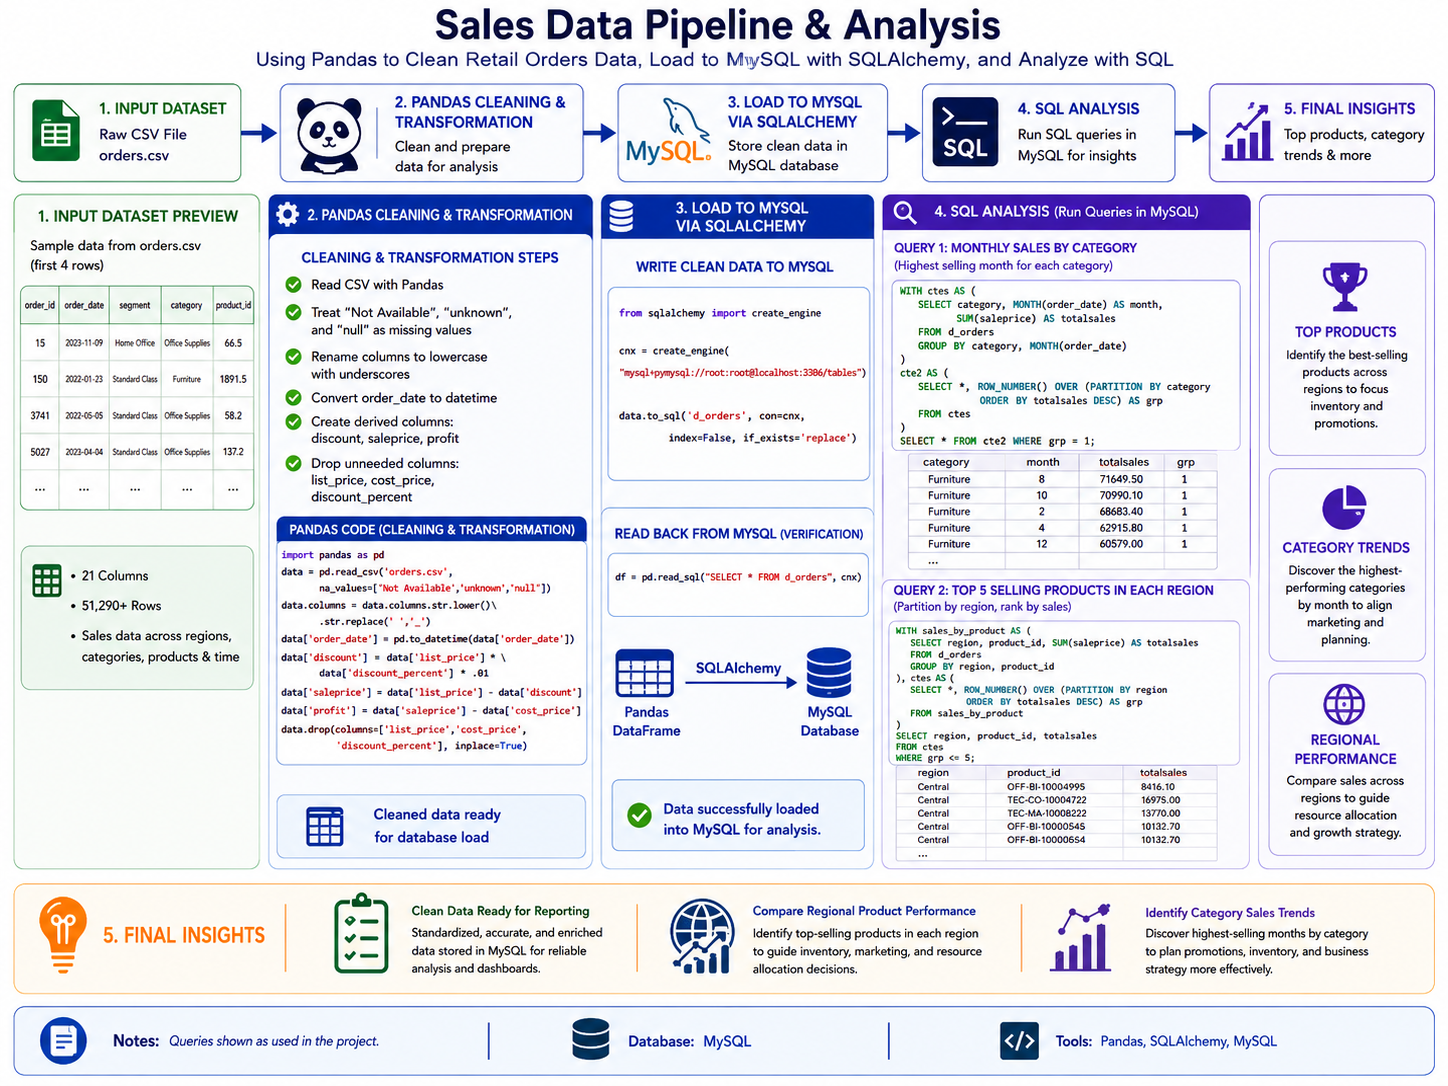

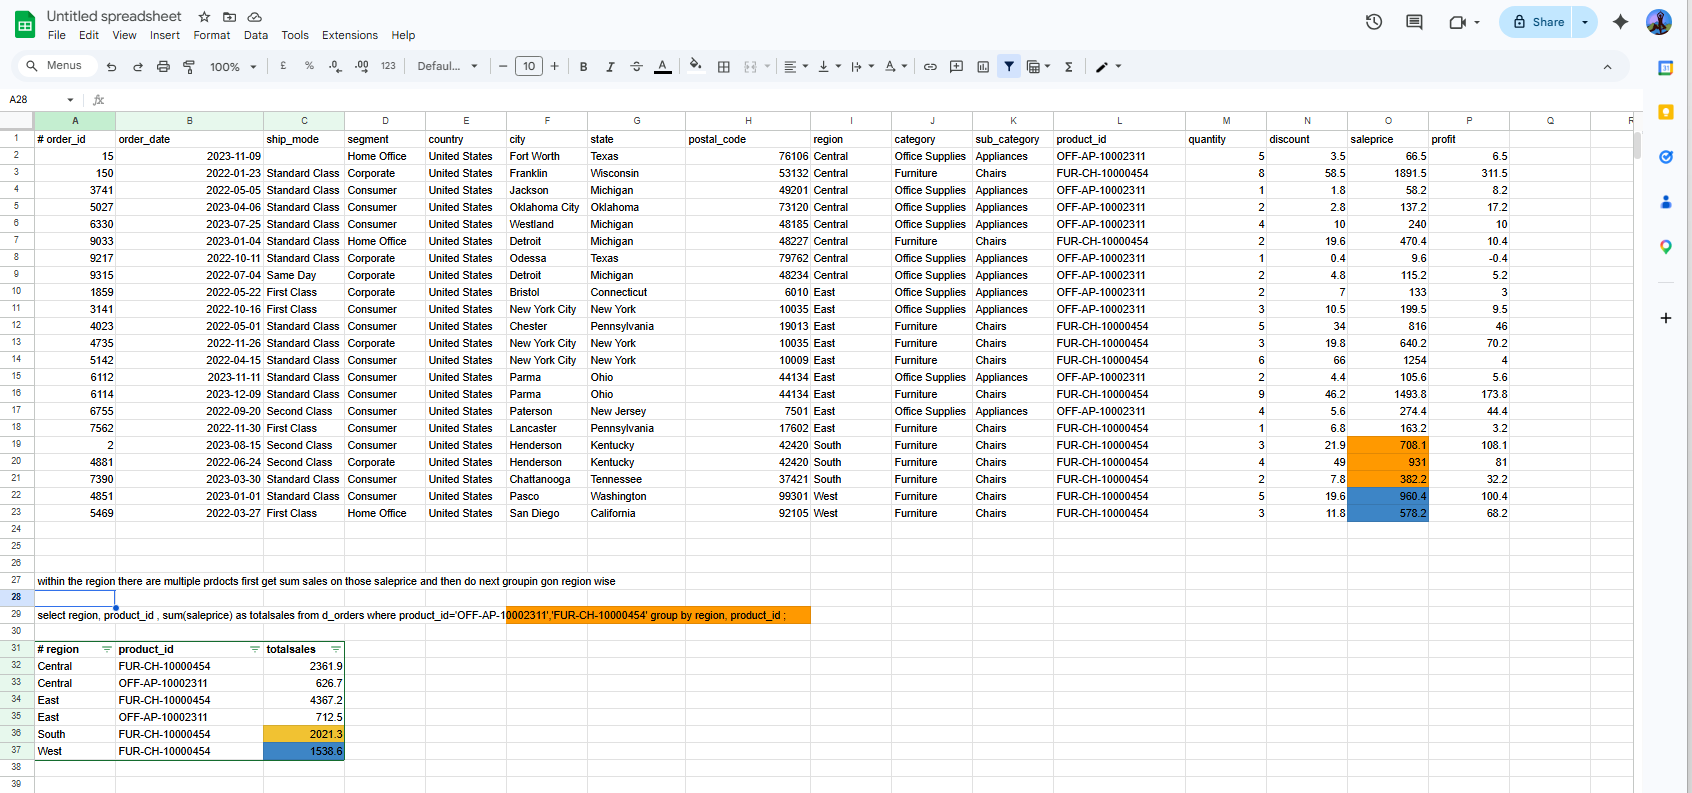

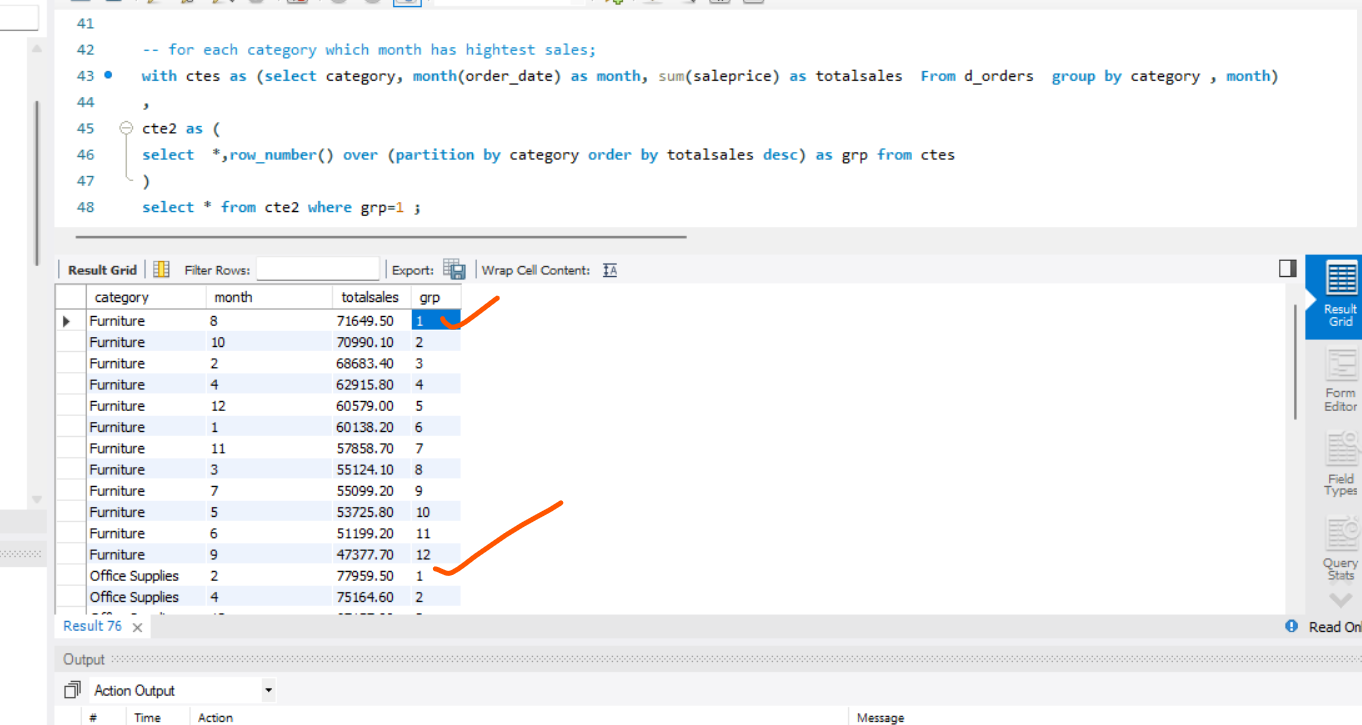

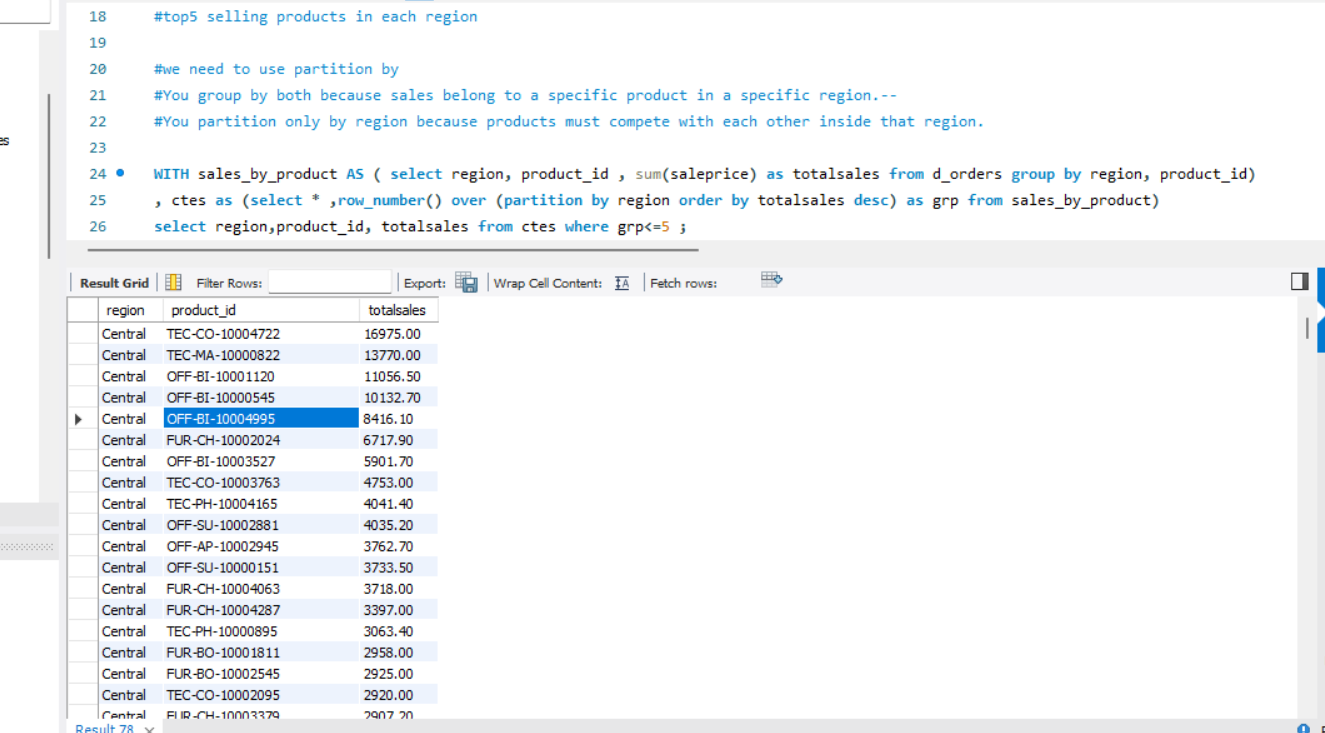